In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle

In [ ]:
!kaggle datasets download -d aashidutt3/waste-segregation-image-dataset

100% 1.17G/1.17G [00:13<00:00, 85.9MB/s]
100% 1.17G/1.17G [00:13<00:00, 93.2MB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/waste-segregation-image-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [ ]:
import tensorflow as tf

def preprocess_image(image, label):
    image = tf.image.resize(image, (256, 256))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/content/Robotics_Dataset/train',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(256, 256),
    validation_split=0.2,
    subset='training',
    seed=123
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/content/Robotics_Dataset/test',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(256, 256),
    validation_split=0.2,
    subset='validation',
    seed=123
)

AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(buffer_size=1000)
    .prefetch(buffer_size=AUTOTUNE)
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
)

validation_ds = (
    validation_ds
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
)


Found 10736 files belonging to 2 classes.
Using 8589 files for training.
Found 298 files belonging to 2 classes.
Using 59 files for validation.


In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/drive/MyDrive/ros_data/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/drive/MyDrive/ros_data/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 10 files belonging to 2 classes.
Found 0 files belonging to 2 classes.


ValueError: ignored

In [ ]:
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

AttributeError: ignored

In [ ]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data generators for training and validation
train_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize pixel values to [0, 1]
train_ds = train_datagen.flow_from_directory('/content/Robotics_Dataset/train', target_size=(224, 224), batch_size=32, class_mode='sparse')

validation_datagen = ImageDataGenerator(rescale=1.0/255.0)
validation_ds = validation_datagen.flow_from_directory('/content/Robotics_Dataset/test', target_size=(224, 224), batch_size=32, class_mode='sparse')

# Define the number of classes in your dataset
num_classes = 2  # Replace this with the actual number of classes

# Define your neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)


Found 10736 images belonging to 2 classes.
Found 298 images belonging to 2 classes.
Epoch 1/10
 22/336 [>.............................] - ETA: 57s - loss: 0.7387 - accuracy: 0.9389

KeyboardInterrupt: ignored

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

# Print train accuracy
train_accuracy = history.history['accuracy']
print("Train Accuracy:", train_accuracy)

# Print validation accuracy
val_accuracy = history.history['val_accuracy']
print("Validation Accuracy:", val_accuracy)


Epoch 1/10
1/1 [==============================] - 16s 16s/step - loss: 1.1989 - accuracy: 0.2500 - val_loss: 0.6640 - val_accuracy: 1.0000
Epoch 2/10
1/1 [==============================] - 0s 69ms/step - loss: 7.3799e-19 - accuracy: 1.0000 - val_loss: 0.6374 - val_accuracy: 1.0000
Epoch 3/10
1/1 [==============================] - 0s 66ms/step - loss: 2.8485e-30 - accuracy: 1.0000 - val_loss: 0.6283 - val_accuracy: 1.0000
Epoch 4/10
1/1 [==============================] - 0s 67ms/step - loss: 4.0470e-30 - accuracy: 1.0000 - val_loss: 0.6443 - val_accuracy: 1.0000
Epoch 5/10
1/1 [==============================] - 0s 66ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.6924 - val_accuracy: 1.0000
Epoch 6/10
1/1 [==============================] - 0s 68ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.7454 - val_accuracy: 0.0000e+00
Epoch 7/10
1/1 [==============================] - 0s 69ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.8129 - val_accuracy: 0.0000

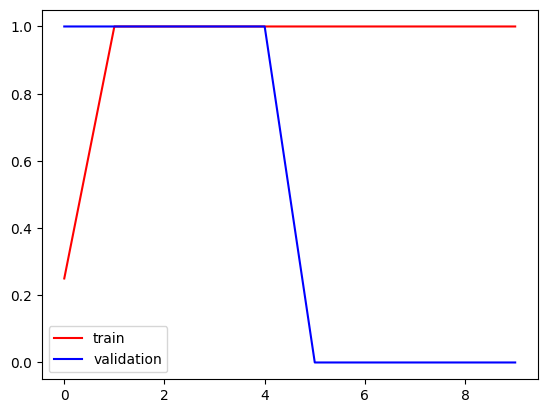

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

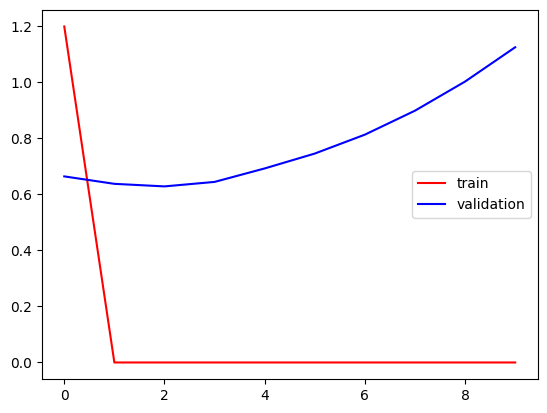

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

1/1 [==============================] - 0s 20ms/step
0


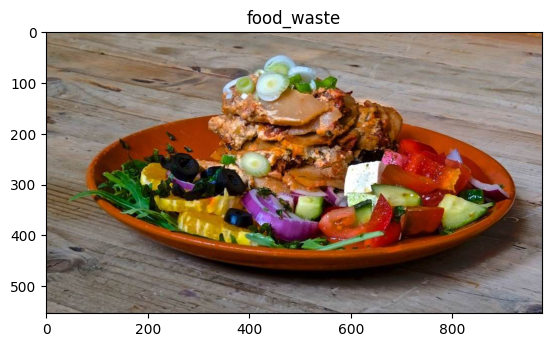

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
test_image=r'/content/Robotics_Dataset/test/food_waste/00000372.jpg'
image_result=Image.open(test_image)

from tensorflow.keras.preprocessing import image
test_image=image.load_img(test_image,target_size=(256,256))
test_image=image.img_to_array(test_image)
test_image=test_image/255
test_image=np.expand_dims(test_image,axis=0)
result=model.predict(test_image)
print(np.argmax(result))
Categories=['food_waste','metal_waste']
image_result=plt.imshow(image_result)
plt.title(Categories[np.argmax(result)])
plt.show()

1/1 [==============================] - 0s 28ms/step
0


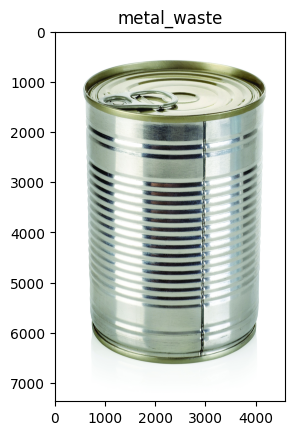

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
test_image=r'/content/Robotics_Dataset/test/metal_cans/00000018.jpg'
image_result=Image.open(test_image)

from tensorflow.keras.preprocessing import image
test_image=image.load_img(test_image,target_size=(256,256))
test_image=image.img_to_array(test_image)
test_image=test_image/255
test_image=np.expand_dims(test_image,axis=0)
result=model.predict(test_image)
print(np.argmax(result))
Categories=['metal_waste','food_waste']
image_result=plt.imshow(image_result)
plt.title(Categories[np.argmax(result)])
plt.show()